In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import re
import joblib
import random
import numpy as np
import scipy as sp
from matplotlib import pyplot as plt
import matplotlib as mpl
from syd import make_viewer, Viewer
from tqdm import tqdm
import optuna

from vrAnalysis.database import get_database
from vrAnalysis.helpers import Timer, get_placefield_location, uniq_val_filter
from vrAnalysis.processors.em import process_session
from vrAnalysis.processors.placefields import get_placefield, get_placefield_prediction, convert_position_to_bins
from vrAnalysis.processors.support import get_gauss_kernel, convolve_toeplitz, smooth
from dimensionality_manuscript.registry import PopulationRegistry
from dimensionality_manuscript import LocPredConfig
from dimensionality_manuscript import ResultsStore, ResultsAggregator

plt.rcParams["font.size"] = 18

# get session database
sessiondb = get_database("vrSessions")

# get population registry and models
registry = PopulationRegistry()
cfg = LocPredConfig(norm_method="zero-one", norm_scale=1.0, fit_iterations=5)

In [3]:
isession = 41
spks_type = "oasis"
session_iterable = sessiondb.iter_sessions(imaging=True, session_params=dict(spks_type=spks_type))

# session = random.choice([s for s in session_iterable if s.mouse_name == "ATL027"])
session = session_iterable[isession]
print(session)
print(session.environments)

fit = cfg.fit(session, registry)
hyperparameters = cfg.optimize(session, registry, fit)
score_null = cfg.score(session, registry, fit, hyperparameters=None, iteration=0)
score = cfg.score(session, registry, fit, hyperparameters=hyperparameters, iteration=0)

# Full process with iterations and stuff
results = cfg.process(session, registry)

B2Session(mouse_name='ATL022', date='2023-04-18', session_id='701', spks_type='oasis')
[1 3]


In [4]:
loss_types = [re.fullmatch(r"poisson_(.+)", k).group(1) for k in score["loss_scalar"].keys() if re.fullmatch(r"poisson_(.+)", k)]
print("Loss types:")
for loss_type in loss_types:
    print(f"  {loss_type}")

print("Likelihood methods:")
print(cfg.likelihood_methods)

print("Results:")
print("\n   ".join(list(results.keys())))

Loss types:
  cross_entropy
  rank_loss_logistic_mean
  rank_loss_hinge_mean
  rank_metric_mean_rank
  rank_metric_top1
  rank_metric_top5
  rank_metric_top10
  distance_error
  env_swap
Likelihood methods:
('poisson', 'gaussian', 'diag_gaussian', 'von_mises_fisher')
Results:
likelihood_matrix
   loss_trajectory
   loss_scalar
   true_bin_score
   true_position_bins_te
   idx_keep_rois
   iteration_position_bins_tr


In [5]:
# For looking how the test scores change across iterations of fit (in EM routine)
method_width = max(len(method) for method in cfg.likelihood_methods)

for loss_type in loss_types:
    print(f"Loss type: {loss_type}")
    for method in cfg.likelihood_methods:
        _scores = np.array(results["loss_scalar"][f"{method}_{loss_type}"])
        _scores = _scores / np.min(_scores)
        _scores = np.array([np.round(s, 3) for s in _scores])
        print(f"  {method.ljust(method_width)}: {_scores}")

Loss type: cross_entropy
  poisson         : [1.    1.135 1.24  1.396 1.579]
  gaussian        : [1.    1.156 1.288 1.413 1.573]
  diag_gaussian   : [1.    1.232 1.633 2.242 3.362]
  von_mises_fisher: [1.    1.224 1.375 1.487 1.589]
Loss type: rank_loss_logistic_mean
  poisson         : [1.    2.261 3.084 4.962 7.217]
  gaussian        : [1.    1.709 2.398 3.199 4.325]
  diag_gaussian   : [ 1.     2.232  4.214 10.775 30.928]
  von_mises_fisher: [1.    2.002 2.831 3.474 3.967]
Loss type: rank_loss_hinge_mean
  poisson         : [1.    2.14  3.107 5.151 8.223]
  gaussian        : [1.    1.729 2.489 3.388 4.74 ]
  diag_gaussian   : [ 1.     2.643  5.073 12.378 33.528]
  von_mises_fisher: [1.    1.958 2.904 3.628 4.213]
Loss type: rank_metric_mean_rank
  poisson         : [1.    1.803 2.818 4.55  6.483]
  gaussian        : [1.    1.706 2.447 3.286 4.496]
  diag_gaussian   : [1.    1.876 2.944 4.554 6.741]
  von_mises_fisher: [1.    1.733 2.433 2.984 3.459]
Loss type: rank_metric_top1
  poi

In [6]:
# For comparing without validation to with validation
method_width = max(len(method) for method in cfg.likelihood_methods)

for loss_type in loss_types:
    print(loss_type)

    for likelihood_method in cfg.likelihood_methods:
        _score_null = score_null["loss_scalar"][f"{likelihood_method}_{loss_type}"]
        _score = score["loss_scalar"][f"{likelihood_method}_{loss_type}"]

        print(f"   {likelihood_method:<{method_width}} : " f"{_score_null:8.2f} -> {_score:8.2f}")

cross_entropy
   poisson          :    13.99 ->     3.77
   gaussian         :     2.93 ->     3.67
   diag_gaussian    :   100.04 ->     2.48
   von_mises_fisher :     5.07 ->     3.32
rank_loss_logistic_mean
   poisson          :     0.39 ->     0.25
   gaussian         :     0.11 ->     0.26
   diag_gaussian    :     2.62 ->     0.06
   von_mises_fisher :     0.58 ->     0.15
rank_loss_hinge_mean
   poisson          :     0.41 ->     0.15
   gaussian         :     0.09 ->     0.20
   diag_gaussian    :     2.64 ->     0.06
   von_mises_fisher :     0.76 ->     0.12
rank_metric_mean_rank
   poisson          :     5.49 ->     5.49
   gaussian         :     8.08 ->     8.08
   diag_gaussian    :     5.74 ->     5.74
   von_mises_fisher :     6.33 ->     6.33
rank_metric_top1
   poisson          :     0.19 ->     0.19
   gaussian         :     0.17 ->     0.17
   diag_gaussian    :     0.20 ->     0.20
   von_mises_fisher :     0.18 ->     0.18
rank_metric_top5
   poisson          :    

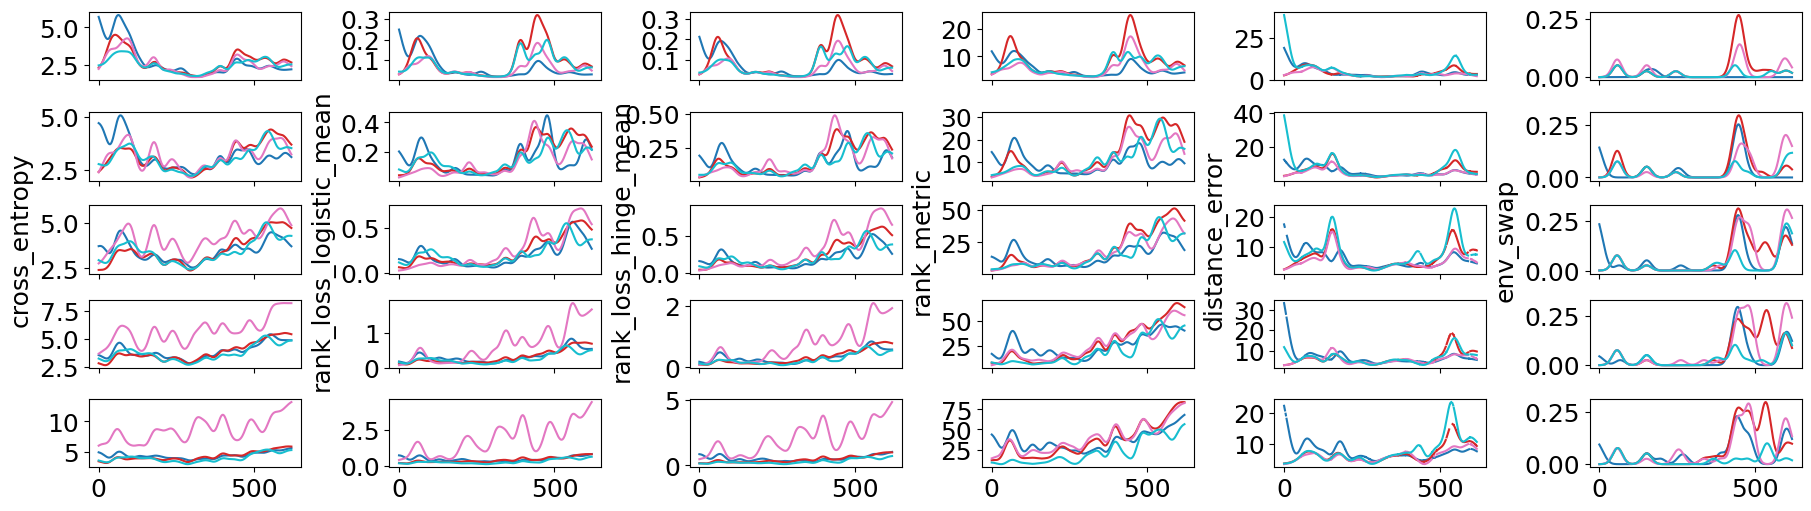

In [7]:
from scipy.stats import zscore

# Get m
num_loss = len(cfg.loss_methods)
num_ll = len(cfg.likelihood_methods)
colors = plt.colormaps["tab10"](np.linspace(0, 1, num_ll))

num_iterations = cfg.fit_iterations
norm = lambda x: x  # zscore(x, axis=-1, nan_policy="omit")

plt.close("all")
fig, ax = plt.subplots(num_iterations, num_loss, figsize=(3 * num_loss, 5), layout="constrained", sharex=True)
for iloss, loss_method in enumerate(cfg.loss_methods):
    for ill, ll_method in enumerate(cfg.likelihood_methods):
        ckey = f"{ll_method}_{loss_method}"
        cval = results["loss_trajectory"][ckey]
        xx = np.arange(cval.shape[-1])
        fval = smooth(cval, xx, 11)
        for iteration in range(num_iterations):
            ax[iteration, iloss].plot(norm(fval[iteration]), color=colors[ill], label=ll_method)
    ax[2, iloss].set_ylabel(loss_method)
    # ax[iloss].legend()

plt.show()

In [8]:
for k, val in results["true_bin_score"].items():
    print(f"{k}: {val.shape}")

poisson: (5, 621)
gaussian: (5, 621)
diag_gaussian: (5, 621)
von_mises_fisher: (5, 621)


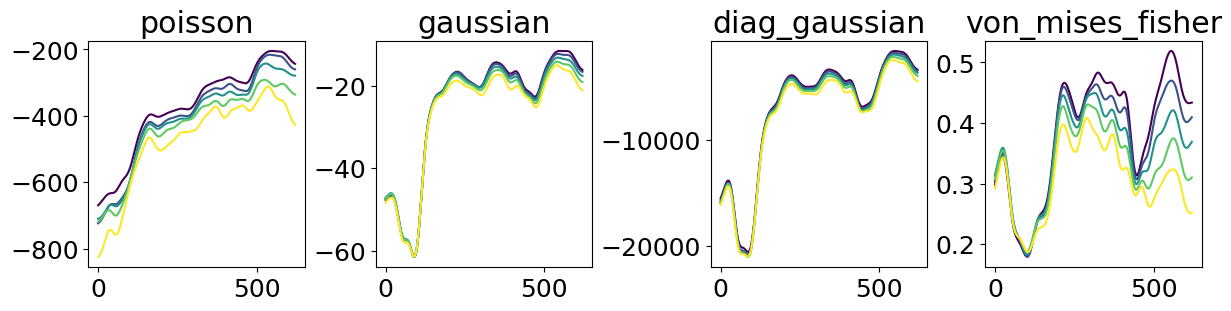

In [9]:
# Get m
num_ll = len(cfg.likelihood_methods)
num_iterations = cfg.fit_iterations
colors = plt.colormaps["viridis"](np.linspace(0, 1, num_iterations))

norm = lambda x: x  # zscore(x, axis=-1, nan_policy="omit")

plt.close("all")
fig, ax = plt.subplots(1, num_ll, figsize=(3 * num_ll, 3), layout="constrained", sharex=True)
for ill, ll_method in enumerate(cfg.likelihood_methods):
    cval = results["true_bin_score"][ll_method]
    xx = np.arange(cval.shape[-1])
    fval = smooth(cval, xx, 11)
    for iteration in range(num_iterations):
        ax[ill].plot(norm(fval[iteration]), color=colors[iteration], label=ll_method)
    ax[ill].set_title(ll_method)

plt.show()

In [ ]:
# ROI selection summary + final-iteration scalar table
n_total = fit.idx_keep_rois.shape[0]
n_kept = int(fit.idx_keep_rois.sum())
print(f"ROIs: {n_kept}/{n_total} kept ({100*n_kept/n_total:.1f}%)")
print()

key_metrics = {
    "cross_entropy": "xent",
    "distance_error": "dist_err",
    "env_swap": "env_swap",
    "rank_metric_top1": "top1",
    "rank_metric_mean_rank": "mean_rank",
}
col_w = 12
header = f"{'likelihood':<22}" + "".join(f"{label:>{col_w}}" for label in key_metrics.values())
print(header)
print("-" * len(header))
for ll in cfg.likelihood_methods:
    row = f"{ll:<22}"
    for metric_key in key_metrics:
        key = f"{ll}_{metric_key}"
        vals = results["loss_scalar"].get(key)
        row += f"{vals[-1]:>{col_w}.4f}" if vals is not None else f"{'N/A':>{col_w}}"
    print(row)

ROIs: 7604/18020 kept (42.2%)

likelihood                    xent    dist_err    env_swap        top1   mean_rank
----------------------------------------------------------------------------------
poisson                     4.3947      7.2487      0.0483      0.0741     35.5781
gaussian                    4.2716      6.4104      0.0741      0.0966     36.3253
diag_gaussian               8.6098      5.8288      0.0596      0.0950     38.7214
von_mises_fisher            3.9689      7.4507      0.0209      0.1111     21.8986


In [ ]:
# EM convergence: key scalars vs. iteration
key_metrics = {
    "cross_entropy": "xent",
    "distance_error": "dist_err (track units)",
    "rank_metric_top1": "top-1 acc",
    "rank_metric_mean_rank": "mean rank",
}
colors = plt.colormaps["tab10"](np.linspace(0, 1, len(cfg.likelihood_methods)))
iterations = np.arange(cfg.fit_iterations)

fig, axes = plt.subplots(1, len(key_metrics), figsize=(4 * len(key_metrics), 3.5), layout="constrained")
for ax, (metric_key, metric_label) in zip(axes, key_metrics.items()):
    for ill, ll in enumerate(cfg.likelihood_methods):
        vals = results["loss_scalar"].get(f"{ll}_{metric_key}")
        if vals is not None:
            ax.plot(iterations, vals, marker="o", color=colors[ill], label=ll)
    ax.set_title(metric_label, fontsize=13)
    ax.set_xlabel("EM iteration")
    ax.set_xticks(iterations)

axes[0].legend(fontsize=9)
plt.suptitle("EM convergence across iterations", fontsize=14)
plt.show()

In [ ]:
# Decoded vs true position (final iteration, diag_gaussian) + distance error distributions
ll_key = "diag_gaussian"
num_bins = cfg.num_bins
bin_centers = (fit.dist_edges[:-1] + fit.dist_edges[1:]) / 2.0
true_bins = results["true_position_bins_te"]
true_pos = bin_centers[true_bins % num_bins]

ll_matrix = results["likelihood_matrix"][ll_key][-1]  # (frames, total_bins)
pred_bins = np.argmax(ll_matrix, axis=1)
pred_pos = bin_centers[pred_bins % num_bins]

colors = plt.colormaps["tab10"](np.linspace(0, 1, len(cfg.likelihood_methods)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4), layout="constrained")

# Left: time-series of decoded vs true position
window = 600
axes[0].plot(true_pos[:window], label="true", alpha=0.75, lw=1.2, color="k")
axes[0].plot(pred_pos[:window], label="decoded", alpha=0.75, lw=1.2, color=colors[2])
axes[0].set_xlabel("frame")
axes[0].set_ylabel("position")
axes[0].set_title(f"True vs decoded ({ll_key}, iter {cfg.fit_iterations - 1})")
axes[0].legend(fontsize=10)

# Right: distance error distribution per likelihood method (final iteration, env-matched frames only)
for ill, ll in enumerate(cfg.likelihood_methods):
    traj = results["loss_trajectory"][f"{ll}_distance_error"][-1]
    valid = traj[~np.isnan(traj)]
    axes[1].hist(valid, bins=60, alpha=0.45, color=colors[ill], label=ll, density=True)
axes[1].set_xlabel("position error (track units)")
axes[1].set_ylabel("density")
axes[1].set_title("Distance error distribution (final EM iteration)")
axes[1].legend(fontsize=9)

plt.show()